In [8]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [9]:
# ---- Core configuration (edit these first) ----
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
BINARY = REPO_ROOT / "iron" / "operators" / "mul_bench" / "mul_bench_parallel_test"
BENCH_DIR = BINARY.parent

SIZE_GPU = 1 << 20
SIZE_NPU = 1 << 20
ITERS_GPU = 1
ITERS_NPU = 1
REPEATS = 3

NPU_COLUMNS = 8
NPU_CHANNELS = 2
NPU_TILE_SZ = 8192

RUN_GPU = True
RUN_NPU = True

print(f"Binary: {BINARY} (exists: {BINARY.exists()})")

Binary: /home/steven/gpu_bench/IRON/iron/operators/mul_bench/mul_bench_parallel_test (exists: True)


In [16]:
def artifact_stem(size_npu, r, num_columns=NPU_COLUMNS, num_channels=NPU_CHANNELS, tile_size=NPU_TILE_SZ):
    return f"MulBench_sz{size_npu}_c{num_columns}_ch{num_channels}_t{tile_size}_R{r}_npu2"


def ensure_npu_artifacts(r, size_npu=None):
    """Compile NPU xclbin/bin for this (size, r) if not already present."""
    if size_npu is None:
        size_npu = SIZE_NPU
    stem  = artifact_stem(size_npu, r)
    build = REPO_ROOT / "build"
    if (build / f"{stem}.xclbin").exists() and (build / f"{stem}.bin").exists():
        return
    print(f"  Compiling NPU artifact for R={r}...", end=" ", flush=True)
    result = subprocess.run(
        [
            sys.executable,
            "iron/operators/mul_bench/run_mul_bench_npu.py",
            "--size",         str(size_npu),
            "--r",            str(r),
            "--num-columns",  str(NPU_COLUMNS),
            "--num-channels", str(NPU_CHANNELS),
            "--tile-size",    str(NPU_TILE_SZ),
        ],
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"NPU compilation failed for R={r}, size={size_npu}:\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    print("done")


def run_bench(r, size_gpu=None, size_npu=None, iters_gpu=None, iters_npu=None, run_gpu=None, run_npu=None, repeats=1):
    if size_gpu  is None: size_gpu  = SIZE_GPU
    if size_npu  is None: size_npu  = SIZE_NPU
    if iters_gpu is None: iters_gpu = ITERS_GPU
    if iters_npu is None: iters_npu = ITERS_NPU
    if run_gpu   is None: run_gpu   = RUN_GPU
    if run_npu   is None: run_npu   = RUN_NPU

    cmd = [
        str(BINARY),
        "--r",         str(r),
        "--size-gpu",  str(size_gpu),
        "--size-npu",  str(size_npu),
        "--iters-gpu", str(iters_gpu),
        "--iters-npu", str(iters_npu),
        "--repeats",   str(repeats),
        "--json",
    ]
    if not run_gpu:
        cmd.append("--no-gpu")
    if not run_npu:
        cmd.append("--no-npu")
    result = subprocess.run(cmd, cwd=str(BENCH_DIR), capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"Binary failed (exit {result.returncode}):\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    last_line = result.stdout.strip().splitlines()[-1]
    return json.loads(last_line)


## Run Your Sweep (Edit and Execute)

Start small first, then scale up.

Example:
- set `R_VALUES`
- run one or more sweep helpers
- call a plotting helper

In [24]:
total_batches = 100 #Total number of batches that will be split amongst the gpu or npu
repeats      = 10 #number of runs the data will be averaged over for each R, will run the number of batches specified in total_batches for each run
R_VALUES = list(range(1, 3000, 50)) #AI = R/2

In [25]:
npu_points      = []
# ── NPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        if RUN_NPU:
            ensure_npu_artifacts(r)
        datan = run_bench(r, iters_npu=total_batches, run_gpu=False, run_npu=True, repeats=repeats)
        n = datan.get("npu")
        if n:
            npu_points.append((n["arith_intensity"], n["tflops"]))

            print(f"NPU {n['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"NPU BW {n['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no NPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(npu_points)} NPU points.")

[1/60] R=    1  AI=0.50 FLOPs/Byte  NPU 0.0142 TFLOPS  NPU BW 28.38 GB/s
[2/60] R=   51  AI=25.50 FLOPs/Byte  NPU 0.7363 TFLOPS  NPU BW 28.88 GB/s
[3/60] R=  101  AI=50.50 FLOPs/Byte  NPU 1.3181 TFLOPS  NPU BW 26.10 GB/s
[4/60] R=  151  AI=75.50 FLOPs/Byte  NPU 1.7809 TFLOPS  NPU BW 23.59 GB/s
[5/60] R=  201  AI=100.50 FLOPs/Byte  NPU 2.1951 TFLOPS  NPU BW 21.84 GB/s
[6/60] R=  251  AI=125.50 FLOPs/Byte  NPU 2.5462 TFLOPS  NPU BW 20.29 GB/s
[7/60] R=  301  AI=150.50 FLOPs/Byte  NPU 2.8431 TFLOPS  NPU BW 18.89 GB/s
[8/60] R=  351  AI=175.50 FLOPs/Byte  NPU 3.1601 TFLOPS  NPU BW 18.01 GB/s
[9/60] R=  401  AI=200.50 FLOPs/Byte  NPU 3.3780 TFLOPS  NPU BW 16.85 GB/s
[10/60] R=  451  AI=225.50 FLOPs/Byte  NPU 3.5857 TFLOPS  NPU BW 15.90 GB/s
[11/60] R=  501  AI=250.50 FLOPs/Byte  NPU 3.7679 TFLOPS  NPU BW 15.04 GB/s
[12/60] R=  551  AI=275.50 FLOPs/Byte  NPU 3.9392 TFLOPS  NPU BW 14.30 GB/s
[13/60] R=  601  AI=300.50 FLOPs/Byte  NPU 4.1025 TFLOPS  NPU BW 13.65 GB/s
[14/60] R=  651  AI=325.50

In [27]:
gpu_points      = []
# ── GPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        datag = run_bench(r, iters_gpu=total_batches, run_gpu=True, run_npu=False, repeats=repeats)
        g = datag.get("gpu")
        if g:
            gpu_points.append((g["arith_intensity"], g["tflops"]))
            print(f"GPU {g['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"GPU BW {g['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no GPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(gpu_points)} GPU points.")

[1/60] R=    1  AI=0.50 FLOPs/Byte  GPU 0.0325 TFLOPS  GPU BW 64.94 GB/s
[2/60] R=   51  AI=25.50 FLOPs/Byte  GPU 1.5989 TFLOPS  GPU BW 62.70 GB/s
[3/60] R=  101  AI=50.50 FLOPs/Byte  GPU 2.9573 TFLOPS  GPU BW 58.56 GB/s
[4/60] R=  151  AI=75.50 FLOPs/Byte  GPU 3.9903 TFLOPS  GPU BW 52.85 GB/s
[5/60] R=  201  AI=100.50 FLOPs/Byte  GPU 4.7840 TFLOPS  GPU BW 47.60 GB/s
[6/60] R=  251  AI=125.50 FLOPs/Byte  GPU 5.8829 TFLOPS  GPU BW 46.88 GB/s
[7/60] R=  301  AI=150.50 FLOPs/Byte  GPU 6.2130 TFLOPS  GPU BW 41.28 GB/s
[8/60] R=  351  AI=175.50 FLOPs/Byte  GPU 6.1196 TFLOPS  GPU BW 34.87 GB/s
[9/60] R=  401  AI=200.50 FLOPs/Byte  GPU 6.4100 TFLOPS  GPU BW 31.97 GB/s
[10/60] R=  451  AI=225.50 FLOPs/Byte  GPU 6.4577 TFLOPS  GPU BW 28.64 GB/s
[11/60] R=  501  AI=250.50 FLOPs/Byte  GPU 6.4973 TFLOPS  GPU BW 25.94 GB/s
[12/60] R=  551  AI=275.50 FLOPs/Byte  GPU 6.4213 TFLOPS  GPU BW 23.31 GB/s
[13/60] R=  601  AI=300.50 FLOPs/Byte  GPU 6.7018 TFLOPS  GPU BW 22.30 GB/s
[14/60] R=  651  AI=325.50

In [ ]:
# specifications for the roofline model, used when use_measured_points=False in bench_with_batch_bias
gpu_perf =  7500
npu_perf =  6400
gpu_mem = 74.5
npu_mem = 30
total_mem = 74.5

def bench_with_batch_bias(rs_values, npu_batch_bias=0, use_measured_points=True):
    """
    npu_batch_bias > 0  => give a few more batches to NPU
    npu_batch_bias < 0  => give a few fewer batches to NPU
    """
    if use_measured_points:
        gpu_lookup = {round(p[0] * 2): p[1] for p in gpu_points}
        npu_lookup = {round(p[0] * 2): p[1] for p in npu_points}
    points = []
    for idx, r in enumerate(rs_values):
        ai = r / 2.0
        try:
            # Same baseline split logic as gpu_npu_sweep.
            if use_measured_points:
                gpu_tf = gpu_lookup.get(r)
                npu_tf = npu_lookup.get(r)
                if gpu_tf is None:
                    raise ValueError(f"No measured GPU point for R={r} — run GPU sweep first with matching R_VALUES")
                if npu_tf is None:
                    raise ValueError(f"No measured NPU point for R={r} — run NPU sweep first with matching R_VALUES")
                gpu_need = gpu_tf * 1000 / ai
                npu_need = npu_tf * 1000 / ai
                mem_cap = min(total_mem, gpu_need + npu_need)
            else:
                gpu_need = min(gpu_perf / ai, gpu_mem)
                npu_need = min(npu_perf / ai, npu_mem)
                mem_cap = min(total_mem, gpu_need + npu_need)

            base_gpu_batches = int(total_batches * (gpu_need / max(mem_cap, 1e-12)))
            base_npu_batches = total_batches - base_gpu_batches
            if base_npu_batches == 0:
                base_npu_batches = 1
                base_gpu_batches = total_batches - 1

            # Apply controlled bias to batch distribution.
            npu_batches = int(np.clip(base_npu_batches + npu_batch_bias, 1, total_batches - 1))
            gpu_batches = total_batches - npu_batches
            data = run_bench(r, iters_gpu=gpu_batches, iters_npu=npu_batches, repeats=repeats)
            tflops = data.get("combined_tflops")
            points.append((ai, tflops, gpu_batches, npu_batches))

            msg = (
                f"[{idx+1}/{len(rs_values)}] R={r:5d} AI={ai:7.2f} "
                f"GPU={gpu_batches:3d} NPU={npu_batches:3d}"
            )
            if tflops is not None:
                msg += f" -> {tflops:.4f} TFLOPS, Combined Bandwidth: {tflops*1000/ai:.2f} GB/s"
            else:
                msg += " -> no result"
            print(msg)
        except Exception as exc:
            print(f"[{idx+1}/{len(rs_values)}] R={r:5d} FAILED: {exc}")
            points.append((ai, None, None, None))
    return points

measured_more_npu_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=+int(np.floor(total_batches/10)), use_measured_points=True)
measured_less_npu_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=-int(np.floor(total_batches/10)), use_measured_points=True)
measured_baseline_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=0, use_measured_points=True)


[1/60] R=    1 AI=   0.50 GPU= 77 NPU= 23 -> 0.0327 TFLOPS, Combined Bandwidth: 65.37 GB/s
[2/60] R=   51 AI=  25.50 GPU= 74 NPU= 26 -> 1.7623 TFLOPS, Combined Bandwidth: 69.11 GB/s
[3/60] R=  101 AI=  50.50 GPU= 68 NPU= 32 -> 3.1276 TFLOPS, Combined Bandwidth: 61.93 GB/s
[4/60] R=  151 AI=  75.50 GPU= 60 NPU= 40 -> 3.9247 TFLOPS, Combined Bandwidth: 51.98 GB/s
[5/60] R=  201 AI= 100.50 GPU= 58 NPU= 42 -> 4.7010 TFLOPS, Combined Bandwidth: 46.78 GB/s
[6/60] R=  251 AI= 125.50 GPU= 59 NPU= 41 -> 5.8318 TFLOPS, Combined Bandwidth: 46.47 GB/s
[7/60] R=  301 AI= 150.50 GPU= 58 NPU= 42 -> 6.1979 TFLOPS, Combined Bandwidth: 41.18 GB/s
[8/60] R=  351 AI= 175.50 GPU= 55 NPU= 45 -> 6.5334 TFLOPS, Combined Bandwidth: 37.23 GB/s
[9/60] R=  401 AI= 200.50 GPU= 55 NPU= 45 -> 7.2223 TFLOPS, Combined Bandwidth: 36.02 GB/s
[10/60] R=  451 AI= 225.50 GPU= 54 NPU= 46 -> 7.5882 TFLOPS, Combined Bandwidth: 33.65 GB/s
[11/60] R=  501 AI= 250.50 GPU= 53 NPU= 47 -> 7.8964 TFLOPS, Combined Bandwidth: 31.52 GB


Summary:
Baseline mean TFLOPS: 10.2940
Measured Baseline mean TFLOPS: 10.8670
More-NPU mean TFLOPS: 8.6926
Less-NPU mean TFLOPS: 10.1024


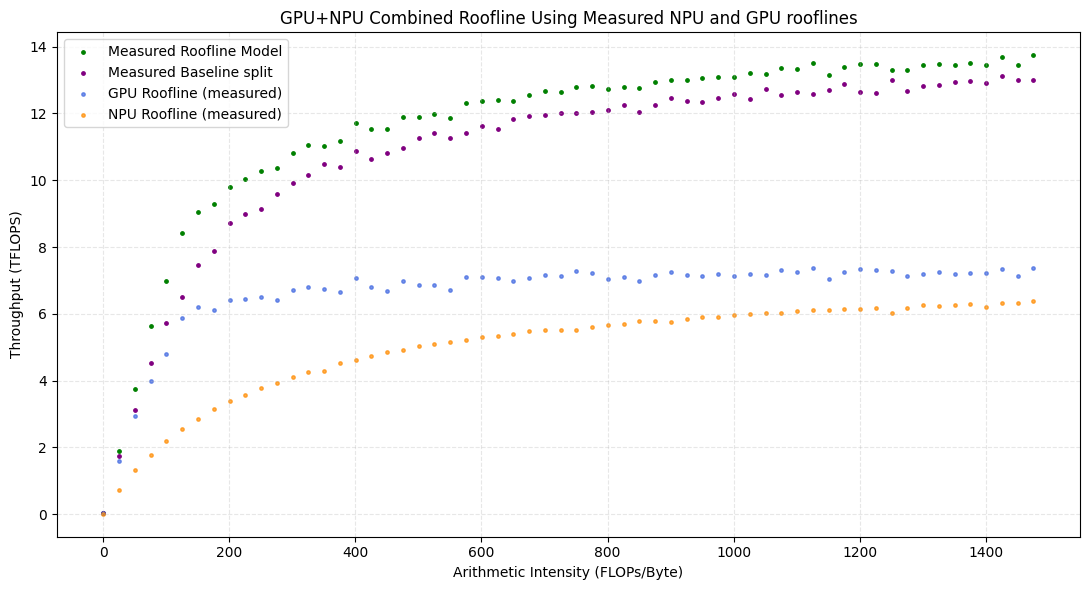

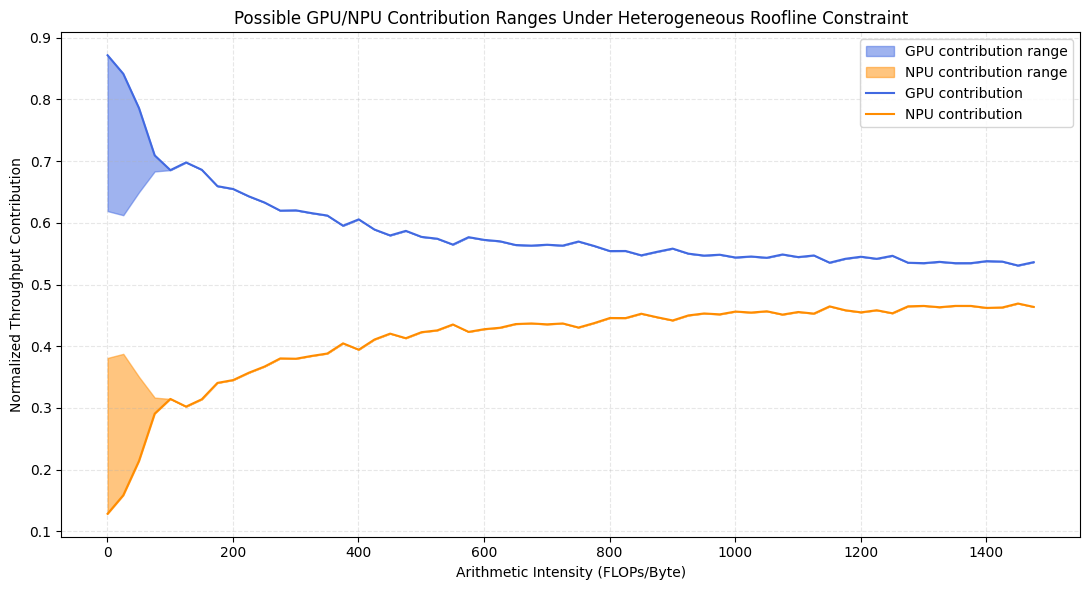

In [ ]:
def to_arrays(points):
    valid = [p for p in points if p[1] is not None]
    if not valid:
        return np.array([]), np.array([])
    return np.array([p[0] for p in valid]), np.array([p[1] for p in valid])


ai_measured_base, t_measured_base = to_arrays(measured_baseline_pts)
ai_measured_more, t_measured_more = to_arrays(measured_more_npu_pts)
ai_measured_less, t_measured_less = to_arrays(measured_less_npu_pts)

# Build aligned GPU/NPU throughput arrays at the same AI points as measured baseline.
gpu_ai_pts = np.array([p[0] for p in gpu_points], dtype=float)
gpu_tf_pts = np.array([p[1] for p in gpu_points], dtype=float)
npu_ai_pts = np.array([p[0] for p in npu_points], dtype=float)
npu_tf_pts = np.array([p[1] for p in npu_points], dtype=float)

if len(ai_measured_base) == 0 or len(gpu_ai_pts) == 0 or len(npu_ai_pts) == 0:
    measured_roofline = np.array([])
else:
    gpu_ref = np.interp(ai_measured_base, gpu_ai_pts, gpu_tf_pts)
    npu_ref = np.interp(ai_measured_base, npu_ai_pts, npu_tf_pts)
    measured_roofline = np.minimum(ai_measured_base * total_mem / 1000.0, gpu_ref + npu_ref)

print("\nSummary:")
if len(t_base):
    print(f"Baseline mean TFLOPS: {t_base.mean():.4f}")
if len(t_measured_base):
    print(f"Measured Baseline mean TFLOPS: {t_measured_base.mean():.4f}")
if len(t_more):
    print(f"More-NPU mean TFLOPS: {t_more.mean():.4f}")
if len(t_less):
    print(f"Less-NPU mean TFLOPS: {t_less.mean():.4f}")
    # Normalize GPU/NPU contributions by hetero roofline (avoid undefined P1/P2/P_het).


if len(ai_measured_base) == 0 or len(measured_roofline) == 0:
    P1_max = np.array([])
    P2_max = np.array([])
    P1_min = np.array([])
    P2_min = np.array([])
else:
    P1 = np.asarray(gpu_ref, dtype=float)   # GPU throughput at baseline AI points
    P2 = np.asarray(npu_ref, dtype=float)   # NPU throughput at baseline AI points
    P_het = measured_roofline  # Heterogeneous roofline at baseline AI points

    P1_max = np.minimum(P1 / P_het, 1.0)
    P2_max = np.minimum(P2 / P_het, 1.0)

    # Lower-bound complements
    P1_min = np.maximum(0.0, 1.0 - P2_max)
    P2_min = np.maximum(0.0, 1.0 - P1_max)

    #actual contributions
    P1_contrib = np.minimum(P1 / P_het, 0.99)
    P2_contrib = np.maximum(0.01, 1.0 - P1_max)



plt.figure(figsize=(11, 6))


plt.scatter(ai_measured_base, measured_roofline, color="green", s = 6, alpha=1, label="Measured Roofline Model")
plt.scatter(ai_measured_base, t_measured_base, color="purple", s = 6, alpha=1, label="Measured Baseline split")
plt.scatter(gpu_ai_pts, gpu_tf_pts, color="royalblue", s = 6, alpha=0.7, label="GPU Roofline (measured)")
plt.scatter(npu_ai_pts, npu_tf_pts, color="darkorange", s = 6, alpha=0.7, label="NPU Roofline (measured)")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")

plt.ylabel("Throughput (TFLOPS)")
plt.title("GPU+NPU Combined Roofline Using Measured NPU and GPU rooflines")

plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6)) 
#want to plot P1_max, P2_max, P1_min, P2_min as stacked area plot to show the range of possible GPU/NPU contributions under the hetero roofline constraint.
plt.fill_between(ai_measured_base, P1_min, P1_max, color="royalblue", alpha=0.5, label="GPU contribution range")
plt.fill_between(ai_measured_base, P2_min, P2_max, color="darkorange", alpha=0.5, label="NPU contribution range")
plt.plot(ai_measured_base, P1_contrib, color="royalblue", linewidth=1.5, label="GPU contribution")
plt.plot(ai_measured_base, P2_contrib, color="darkorange", linewidth=1.5, label="NPU contribution")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Normalized Throughput Contribution")
plt.title("Possible GPU/NPU Contribution Ranges Under Heterogeneous Roofline Constraint")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()